# 📊 Método Elbow y Silhouette: cómo elegir k en K-Means de forma razonada

En este cuaderno exploramos dos criterios complementarios para seleccionar el número de clusters en K-Means: el método del codo (Elbow) y la métrica de Silhouette. No solo generaremos las curvas, sino que también explicaremos qué representan, por qué escalar las variables antes de aplicar K-Means, y cómo balancear evidencia cuantitativa con interpretabilidad de negocio. Trabajaremos con el dataset clásico Iris por su simplicidad y valor pedagógico, pero las ideas son transferibles a problemas reales.

## 🎯 Objetivos
- Entender por qué K-Means requiere elegir k y cuáles son las consecuencias de una mala elección.
- Construir y leer la curva de Elbow (inertia/SSE) para detectar el punto de rendimientos decrecientes.
- Construir y leer la curva de Silhouette para evaluar separación y compacidad de clusters.
- Tomar una decisión informada combinando ambas métricas con criterios prácticos e interpretabilidad.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## 🧰 Librerías y glosario breve
- pandas/numpy: manipulación y cálculo numérico.
- scikit-learn: StandardScaler para escalar variables, KMeans para clustering, Silhouette para calidad de la partición, y PCA opcional para visualización.
- matplotlib: visualización de curvas y dispersión.

Nota: Escalamos antes de K-Means porque la distancia euclídea es sensible a la escala; si una variable tiene magnitud mayor, dominará el resultado.

In [9]:
iris = load_iris()
X = iris.data
df = pd.DataFrame(X, columns=iris.feature_names)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


## 📦 Dataset Iris y expectativas
Cargamos el conjunto Iris, que contiene medidas de sépalos y pétalos de tres especies de flores. Es un ejemplo estándar donde K-Means suele identificar 2–3 grupos razonables. No usamos la etiqueta (especies) para entrenar; se trata de un problema no supervisado y la etiqueta solo sirve para validar a posteriori si los clusters tienen sentido biológico.

## ⚖️ ¿Por qué escalar antes de K-Means?
K-Means minimiza la suma de distancias euclídeas al centroide. Si las variables están en magnitudes distintas (por ejemplo, milímetros vs centímetros), la más grande domina la distancia y sesga la solución. StandardScaler centra en 0 y escala a varianza 1, haciendo comparables las dimensiones y mejorando la estabilidad y la interpretabilidad de los clusters.

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

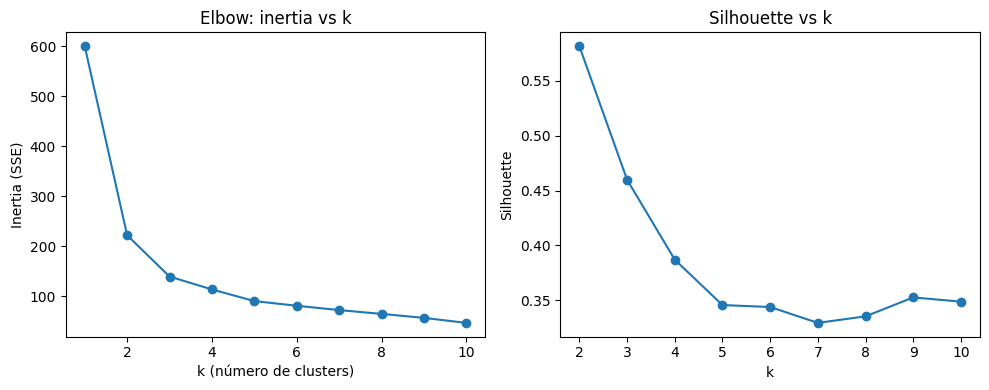

In [11]:
ks = list(range(1, 11)) # Probamos K del 1 al 10
inertias = []
sil_scores = []

for k in ks:
    km = KMeans(n_clusters=max(1,k), random_state=0).fit(X_scaled)
    inertias.append(km.inertia_)
    # silhouette sólo es válida si 2 <= n_clusters <= n_samples-1
    if 2 <= k <= X_scaled.shape[0] - 1:
        sil = silhouette_score(X_scaled, km.labels_)
    else:
        sil = np.nan
    sil_scores.append(sil)


plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(ks, inertias, marker='o')
plt.xlabel('k (número de clusters)')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow: inertia vs k')

plt.subplot(1,2,2)
plt.plot(ks, sil_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette')
plt.title('Silhouette vs k')
plt.tight_layout()
plt.show()

## 🔎 Cómo leer Elbow y Silhouette
- Elbow (Inertia/SSE): siempre decrece al aumentar k. Busca un punto donde la pendiente se aplana de forma notable (el “codo”): a partir de ahí, ganar más con k extra es marginal.
- Silhouette: valores en [−1, 1]; cuanto más alto, mejor separación y compacidad. Observa picos o mesetas altas. Silhouette puede bajar si fuerzas demasiados clusters.

Decisión informada:
- Comienza con el codo como rango candidato de k.
- Dentro de ese rango, elige el k con Silhouette más alto que aún sea interpretable para el negocio (menos segmentos suele facilitar la acción).
- Si ambas métricas discrepan, prioriza consistencia y sentido práctico: estabilidad en re-muestras y facilidad operativa.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


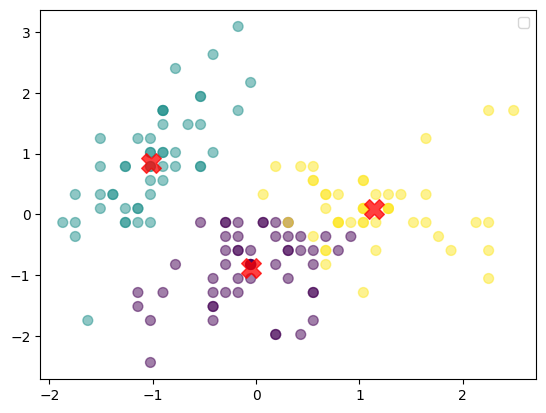

In [12]:
kmeans =  KMeans(n_clusters = 3, init = 'k-means++', max_iter= 300, n_init=10, random_state=0)
kmeans.fit(X_scaled)

cluster_labels = kmeans.labels_

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=cluster_labels, cmap = "viridis", s= 50, alpha = 0.5)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c='red', s=200, alpha=0.75, marker='X')
plt.legend()
plt.show()

## ✅ Conclusiones y siguientes pasos
- Elbow y Silhouette son guías, no reglas duras; buscan equilibrio entre ajuste y simplicidad.
- Tras elegir k, revisa los centroides y la dispersión para entender qué describe cada cluster.
- Siguientes pasos posibles: validar estabilidad con diferentes semillas, probar estandarizaciones alternativas o reducir dimensión con PCA y comparar resultados.